In [6]:
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
from scipy.ndimage import gaussian_filter
import torch

In [2]:
MODEL_NAME = "depth-anything/Depth-Anything-V2-Base-hf"
TEST_IMAGE = "your_image.jpg"
CLEANUP_ENABLED = True
THRESHOLD = 0.03
SIGMA = 1.5

In [3]:
print(f"Loading {MODEL_NAME}...")
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = AutoModelForDepthEstimation.from_pretrained(MODEL_NAME)
model.eval()

Loading depth-anything/Depth-Anything-V2-Base-hf...


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

DepthAnythingForDepthEstimation(
  (backbone): Dinov2Backbone(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_

In [4]:
image = Image.open("test_image.png").convert("RGB")
inputs = processor(images=image, return_tensors="pt")

start = time.time()
with torch.no_grad():
    depth = model(**inputs).predicted_depth
elapsed = time.time() - start

depth_norm = (depth - depth.min()) / (depth.max() - depth.min())
print(f"Quality: visual below")
print(f"Speed: {elapsed:.3f}s")
print(f"Cost: free (local inference)")

Quality: visual below
Speed: 1.263s
Cost: free (local inference)


In [7]:
if CLEANUP_ENABLED:
    depth_arr = depth_norm.squeeze().numpy()
    
    # Threshold background
    depth_arr[depth_arr < THRESHOLD] = 0
    
    # Smooth subject only
    mask = depth_arr > 0
    if mask.sum() > 0:
        depth_arr[mask] = gaussian_filter(depth_arr[mask], sigma=SIGMA)
        # Normalize to 0.35-1.0
        dmin = depth_arr[mask].min()
        dmax = depth_arr[mask].max()
        depth_arr[mask] = 0.35 + (depth_arr[mask] - dmin) / (dmax - dmin) * 0.65
    
    depth_final = depth_arr
    print("Cleanup applied.")
else:
    depth_final = depth_norm.squeeze().numpy()
    print("No cleanup.")

Cleanup applied.


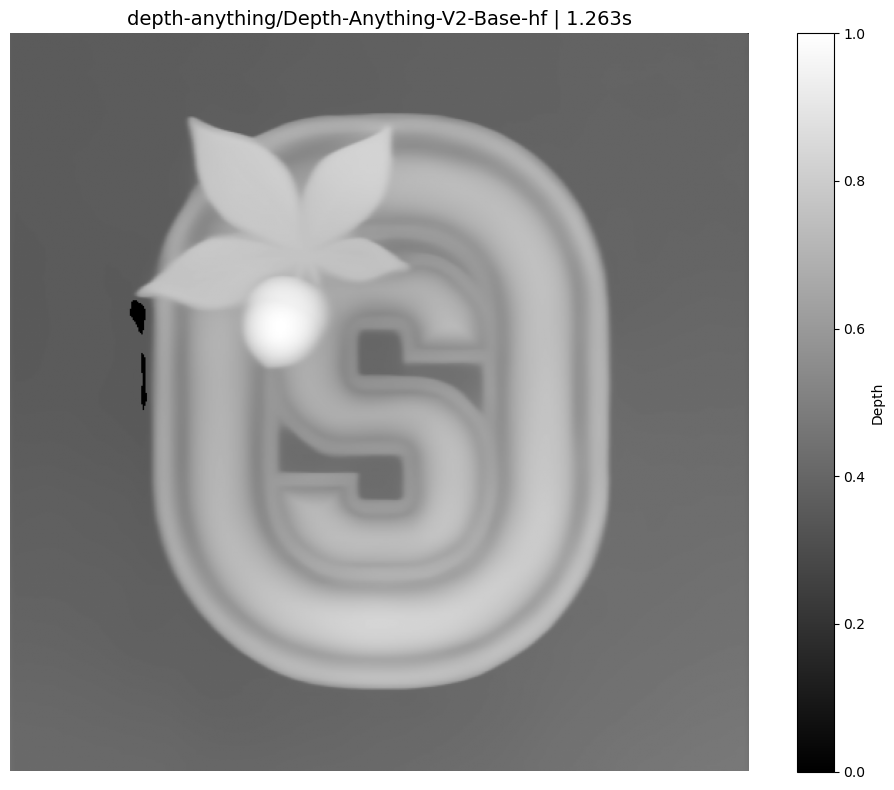

Saved: depth-anything_Depth-Anything-V2-Base-hf_output.png


In [8]:
plt.figure(figsize=(10, 8))
plt.imshow(depth_final, cmap='gray')
plt.colorbar(label='Depth')
plt.title(f"{MODEL_NAME} | {elapsed:.3f}s", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# Save output
result = Image.fromarray((depth_final * 255).astype('uint8'))
output_name = MODEL_NAME.replace("/", "_") + "_output.png"
result.save(output_name)
print(f"Saved: {output_name}")